# Imports

In [2]:
from __future__ import annotations

import base64
import io
import os
import sys
import warnings
from pathlib import Path
from typing import Optional, Tuple, Dict, List, Any

import matplotlib

# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from flask import Flask, request
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

In [3]:
try:
    import shap

    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("Warning: SHAP not available. SHAP analysis will be skipped.")

try:
    from autogluon.tabular import TabularPredictor

    TABULAR_AVAILABLE = True
except ImportError:
    TABULAR_AVAILABLE = False
    print("Warning: AutoGluon Tabular not available.")

# try:
#     from autogluon.multimodal import MultiModalPredictor
#     MULTIMODAL_AVAILABLE = True
# except ImportError:
#     MULTIMODAL_AVAILABLE = False
#     print("Warning: AutoGluon MultiModal not available.")

# try:
#     from autogluon.timeseries import TimeSeriesPredictor, TimeSeriesDataFrame
#     TIMESERIES_AVAILABLE = True
# except ImportError:
#     TIMESERIES_AVAILABLE = False
#     print("Warning: AutoGluon TimeSeries not available.")

try:
    from sklearn.inspection import permutation_importance, partial_dependence

    SKLEARN_INSPECTION_AVAILABLE = True
except ImportError:
    SKLEARN_INSPECTION_AVAILABLE = False
    print("Warning: sklearn.inspection not available.")

In [4]:
import pandas as pd
import requests
from dotenv import find_dotenv, load_dotenv
from fastapi import FastAPI, File, Form, UploadFile, Request, Header
from fastapi.responses import JSONResponse
import tempfile
import shutil
import zipfile

In [5]:
DEFAULT_MAX_SHAP_SAMPLES = 300
DEFAULT_MAX_EMBEDDING_SAMPLES = 1000
DEFAULT_PORT = 5005

# Utils

In [6]:
# =============================================================================
# SECTION 1: UTILITY FUNCTIONS
# =============================================================================


def fig_to_base64(fig) -> str:
    """Convert matplotlib figure to base64-encoded PNG string."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")


def safe_compute(
    func, error_list: List[str], default_value=None, error_prefix="Operation"
):
    """Execute function with error handling and logging."""
    try:
        return func()
    except Exception as e:
        error_msg = f"{error_prefix}: {str(e)}"
        error_list.append(error_msg)
        print(f"Warning: {error_msg}")
        return default_value


In [7]:

# =============================================================================
# SECTION 2: MODEL TYPE DETECTION
# =============================================================================

def detect_model_type(model) -> Tuple[str, str]:
    """
    Detect model type for appropriate explainability selection.

    Returns:
        Tuple[str, str]: (primary_type, sub_type)
        - primary_type: 'autogluon' or 'generic'
        - sub_type: specific model type
    """
    class_name = type(model).__name__
    module_path = type(model).__module__

    print(f"Detecting model type: class={class_name}, module={module_path}")

    # Check AutoGluon first
    if 'TabularPredictor' in class_name or 'autogluon.tabular' in module_path:
        return 'autogluon', 'tabular'
    elif 'MultiModalPredictor' in class_name or 'autogluon.multimodal' in module_path:
        return 'autogluon', 'multimodal'
    elif 'TimeSeriesPredictor' in class_name or 'autogluon.timeseries' in module_path:
        return 'autogluon', 'timeseries'

    # Check generic models - tree-based
    if any(x in class_name for x in ['XGB', 'xgboost', 'XGBoost']):
        return 'generic', 'xgboost'
    elif any(x in class_name for x in ['LGB', 'lightgbm', 'LightGBM']):
        return 'generic', 'lightgbm'
    elif any(x in class_name for x in ['RandomForest', 'GradientBoosting', 'DecisionTree', 'ExtraTree']):
        return 'generic', 'sklearn_tree'
    elif 'CatBoost' in class_name:
        return 'generic', 'catboost'

    # Linear models
    elif any(x in class_name for x in ['Linear', 'Logistic', 'Ridge', 'Lasso', 'ElasticNet', 'SGD']):
        return 'generic', 'linear'

    # Ensemble models
    elif any(x in class_name for x in ['Voting', 'Stacking', 'Bagging', 'AdaBoost']):
        return 'generic', 'ensemble'

    # Neural networks
    elif any(x in class_name for x in ['Sequential', 'Model', 'Keras', 'torch', 'pytorch']):
        return 'generic', 'neural_network'

    # Other models
    elif any(x in class_name for x in ['SVC', 'SVR', 'SVM']):
        return 'generic', 'svm'
    elif any(x in class_name for x in ['KNeighbors', 'KNN']):
        return 'generic', 'knn'
    elif any(x in class_name for x in ['NaiveBayes', 'GaussianNB', 'MultinomialNB']):
        return 'generic', 'naive_bayes'

    return 'generic', 'unknown'


def ensure_numeric(X: pd.DataFrame) -> pd.DataFrame:
    """Convert categorical columns to numeric for visualization."""
    X_numeric = X.copy()

    for col in X_numeric.columns:
        if X_numeric[col].dtype == 'object':
            try:
                from sklearn.preprocessing import LabelEncoder
                le = LabelEncoder()
                X_numeric[col] = le.fit_transform(X_numeric[col].astype(str))
            except:
                # Drop column if encoding fails
                X_numeric = X_numeric.drop(columns=[col])

    return X_numeric

# AutoDW utils

In [8]:
def download_file(url: str, dst: Path, timeout: int = 30) -> None:
    with requests.get(url, stream=True, timeout=timeout) as resp:
        resp.raise_for_status()
        with open(dst, "wb") as f:
            for chunk in resp.iter_content(chunk_size=8192):
                f.write(chunk)


def extract_zip(src: Path, dst: Path) -> None:
    dst.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(src, "r") as zip_ref:
        zip_ref.extractall(dst)


def get_model_metadata(base_url: str, user_id: str, model_id: str) -> dict:
    url = f"{base_url}/ai-models/{user_id}/{model_id}"
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    return resp.json()

def prepare_dataset(base_url: str, USER_ID:str, DATASET_ID:str, DATASET_PATH: Path) -> pd.DataFrame:
    dataset_url = f"{base_url}/datasets/{USER_ID}/{DATASET_ID}/download"
    download_file(dataset_url, DATASET_PATH)
    return pd.read_csv(DATASET_PATH)


def prepare_model(base_url: str, USER_ID:str, MODEL_ID:str, MODEL_ZIP_PATH:Path, EXTRACTED_DIR:Path, AUTOML_MODEL_DIR:Path) -> TabularPredictor:
    model_base = f"{base_url}/ai-models/{USER_ID}/{MODEL_ID}"
    model_download_url = f"{model_base}/download"

    download_file(model_download_url, MODEL_ZIP_PATH)

    extract_zip(MODEL_ZIP_PATH, EXTRACTED_DIR)
    extract_zip(EXTRACTED_DIR / "automl_predictor.zip", AUTOML_MODEL_DIR)

    return TabularPredictor.load(str(AUTOML_MODEL_DIR))

# SHAP

In [51]:
class AutogluonWrapper:
    def __init__(self, predictor, feature_names):
        self.ag_model = predictor
        self.feature_names = feature_names

    def _to_dataframe(self, X):
        if isinstance(X, pd.Series):
            X = X.values.reshape(1, -1)
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names)
        return X

    def predict(self, X):
        X = self._to_dataframe(X)
        # Returns a DataFrame: columns = class labels
        return self.ag_model.predict_proba(X)

def select_shap_explainer(model, X_sample: pd.DataFrame, model_subtype: str):
    """
    Auto-select best SHAP explainer for model type.

    Returns:
        Tuple[explainer, explainer_name] or (None, None) if SHAP unavailable
    """
    if not SHAP_AVAILABLE:
        return None, None

    print(f"Selecting SHAP explainer for model type: {model_subtype}")

    # Tree-based models: Use TreeExplainer (fast, exact)
    if model_subtype in ['xgboost', 'lightgbm', 'catboost', 'sklearn_tree']:
        try:
            explainer = shap.TreeExplainer(model)
            print("Using TreeExplainer")
            return explainer, 'TreeExplainer'
        except Exception as e:
            print(f"TreeExplainer failed: {e}, trying fallback")

    # Linear models: Use LinearExplainer
    if model_subtype == 'linear':
        try:
            explainer = shap.LinearExplainer(model, X_sample)
            print("Using LinearExplainer")
            return explainer, 'LinearExplainer'
        except Exception as e:
            print(f"LinearExplainer failed: {e}, trying fallback")

    # Fallback: KernelExplainer (slow but universal)
    try:
        background = X_sample.sample(n=min(50, len(X_sample)), random_state=42)
        explainer = shap.KernelExplainer(model.predict, background)
        print("Using KernelExplainer (slow but universal)")
        return explainer, 'KernelExplainer'
    except Exception as e:
        print(f"KernelExplainer failed: {e}")
        return None, None


def plot_shap_summary(explainer, X_sample: pd.DataFrame, max_samples: int = 300) -> Optional[str]:
    """Generate SHAP summary plot."""
    if not SHAP_AVAILABLE or explainer is None:
        return None
    
    try:
        X_plot = X_sample.sample(n=min(max_samples, len(X_sample)), random_state=42)
        shap_values = explainer.shap_values(X_plot)
        
        # Handle multi-class output
        if isinstance(shap_values, list) and len(shap_values) > 0:
            shap_values = shap_values[0]
        
        fig = plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_plot, plot_type="bar", max_display=20, show=False)
        plt.title("SHAP Feature Importance", fontsize=14, fontweight="bold", pad=20)
        plt.tight_layout()
        
        return fig_to_base64(fig)
    except Exception as e:
        print(f"SHAP summary plot failed: {e}")
        return None

def plot_shap_summary_fig_view_patch(explainer, X_sample: pd.DataFrame, max_samples: int = 300) -> Optional[str]:
    """Generate SHAP summary plot."""
    if not SHAP_AVAILABLE or explainer is None:
        return None
    
    try:
        X_plot = X_sample.sample(n=min(max_samples, len(X_sample)), random_state=42)
        shap_values = explainer.shap_values(X_plot)
        
        # Handle multi-class output
        if isinstance(shap_values, list) and len(shap_values) > 0:
            shap_values = shap_values[0]
        
        fig = plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_plot, plot_type="bar", max_display=20, show=False)
        plt.title("SHAP Feature Importance", fontsize=14, fontweight="bold", pad=20)
        plt.tight_layout()
        
        # return fig_to_base64(fig)
        return fig
    except Exception as e:
        print(f"SHAP summary plot failed: {e}")
        return None

# TSNE and PCA

In [71]:
def plot_embeddings_tsne_fig_patch(embeddings: np.ndarray, y: Optional[pd.Series] = None) -> Optional[str]:
    """Generate t-SNE plot of embeddings."""
    try:
        if embeddings.shape[0] < 2:
            return None
        
        tsne = TSNE(n_components=2, random_state=42)
        components = tsne.fit_transform(embeddings)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        
        if y is not None:
            class_labels, class_ids = pd.factorize(y)
            scatter = ax.scatter(components[:, 0], components[:, 1],
                                c=class_labels, cmap="viridis", alpha=0.6,
                                edgecolors='k', linewidth=0.5, s=50)
            handles = [plt.Line2D([0], [0], marker='o', color='w',
                                markerfacecolor=scatter.cmap(scatter.norm(i)),
                                markersize=8, label=str(label))
                      for i, label in enumerate(class_ids)]
            ax.legend(handles=handles, title="Class", loc="best")
        else:
            ax.scatter(components[:, 0], components[:, 1],
                      alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
        
        ax.set_xlabel("t-SNE 1", fontsize=12)
        ax.set_ylabel("t-SNE 2", fontsize=12)
        ax.set_title("t-SNE of Embeddings", fontsize=14, fontweight="bold")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        
        # return fig_to_base64(fig)
        return fig
    except Exception as e:
        print(f"Embeddings t-SNE plot failed: {e}")
        return None

def plot_embeddings_tsne(embeddings: np.ndarray, y: Optional[pd.Series] = None) -> Optional[str]:
    """Generate t-SNE plot of embeddings."""
    try:
        if embeddings.shape[0] < 2:
            return None
        
        tsne = TSNE(n_components=2, random_state=42)
        components = tsne.fit_transform(embeddings)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        
        if y is not None:
            class_labels, class_ids = pd.factorize(y)
            scatter = ax.scatter(components[:, 0], components[:, 1],
                                c=class_labels, cmap="viridis", alpha=0.6,
                                edgecolors='k', linewidth=0.5, s=50)
            handles = [plt.Line2D([0], [0], marker='o', color='w',
                                markerfacecolor=scatter.cmap(scatter.norm(i)),
                                markersize=8, label=str(label))
                      for i, label in enumerate(class_ids)]
            ax.legend(handles=handles, title="Class", loc="best")
        else:
            ax.scatter(components[:, 0], components[:, 1],
                      alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
        
        ax.set_xlabel("t-SNE 1", fontsize=12)
        ax.set_ylabel("t-SNE 2", fontsize=12)
        ax.set_title("t-SNE of Embeddings", fontsize=14, fontweight="bold")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        
        return fig_to_base64(fig)
    except Exception as e:
        print(f"Embeddings t-SNE plot failed: {e}")
        return None


In [75]:
def plot_embeddings_pca_fig_patch(embeddings: np.ndarray, y: Optional[pd.Series] = None) -> Optional[str]:
    """Generate PCA plot of embeddings."""
    try:
        if embeddings.shape[1] < 2:
            return None
        
        pca = PCA(n_components=min(2, embeddings.shape[1]))
        components = pca.fit_transform(embeddings)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        
        if y is not None:
            class_labels, class_ids = pd.factorize(y)
            scatter = ax.scatter(components[:, 0], components[:, 1],
                                c=class_labels, cmap="viridis", alpha=0.6,
                                edgecolors='k', linewidth=0.5, s=50)
            handles = [plt.Line2D([0], [0], marker='o', color='w',
                                markerfacecolor=scatter.cmap(scatter.norm(i)),
                                markersize=8, label=str(label))
                      for i, label in enumerate(class_ids)]
            ax.legend(handles=handles, title="Class", loc="best")
        else:
            ax.scatter(components[:, 0], components[:, 1],
                      alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
        
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
        if components.shape[1] > 1:
            ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
        ax.set_title("PCA of Embeddings", fontsize=14, fontweight="bold")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        
        # return fig_to_base64(fig)
        return fig
    except Exception as e:
        print(f"Embeddings PCA plot failed: {e}")
        return None

def plot_embeddings_pca(embeddings: np.ndarray, y: Optional[pd.Series] = None) -> Optional[str]:
    """Generate PCA plot of embeddings."""
    try:
        if embeddings.shape[1] < 2:
            return None
        
        pca = PCA(n_components=min(2, embeddings.shape[1]))
        components = pca.fit_transform(embeddings)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        
        if y is not None:
            class_labels, class_ids = pd.factorize(y)
            scatter = ax.scatter(components[:, 0], components[:, 1],
                                c=class_labels, cmap="viridis", alpha=0.6,
                                edgecolors='k', linewidth=0.5, s=50)
            handles = [plt.Line2D([0], [0], marker='o', color='w',
                                markerfacecolor=scatter.cmap(scatter.norm(i)),
                                markersize=8, label=str(label))
                      for i, label in enumerate(class_ids)]
            ax.legend(handles=handles, title="Class", loc="best")
        else:
            ax.scatter(components[:, 0], components[:, 1],
                      alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
        
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
        if components.shape[1] > 1:
            ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
        ax.set_title("PCA of Embeddings", fontsize=14, fontweight="bold")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        
        return fig_to_base64(fig)
    except Exception as e:
        print(f"Embeddings PCA plot failed: {e}")
        return None

# INFO (and test dataset info)

In [52]:
# ---------------------------------------------------------------------
# Config & setup
# ---------------------------------------------------------------------

load_dotenv(find_dotenv())

AUTODW_URL = os.getenv("AUTODW_URL", "http://localhost:8000")
USER_ID = "1"
MODEL_ID = "automl_2_1765287995"
TARGET_COL = "signature"

DATASET_ID = MODEL_ID.split("_")[1]

TMP_DIR = Path("temporary_dir")
TMP_DIR.mkdir(exist_ok=True)

DATASET_PATH = TMP_DIR / "dataset.csv"
MODEL_ZIP_PATH = TMP_DIR / f"{MODEL_ID}_v1.zip"
EXTRACTED_DIR = TMP_DIR / "extracted"
AUTOML_MODEL_DIR = TMP_DIR / "automl_predictor"

app = FastAPI()

# Get dataset and predictor and process

In [53]:
model_metadata = get_model_metadata(AUTODW_URL, USER_ID, MODEL_ID)
framework = model_metadata.get("framework")

if framework != "sklearn":
    raise ValueError(f"Unsupported framework: {framework}")

df = prepare_dataset(AUTODW_URL, USER_ID, DATASET_ID, DATASET_PATH)

data_info = {
    "shape": df.shape,
    "columns": list(df.columns),
    "dtypes": {c: str(t) for c, t in df.dtypes.items()},
}

print(f"Loaded data: shape={df.shape}, columns={len(df.columns)}")

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

predictor = prepare_model(AUTODW_URL, USER_ID, MODEL_ID, MODEL_ZIP_PATH, EXTRACTED_DIR, AUTOML_MODEL_DIR)

Loaded data: shape=(10000, 19), columns=19


# Run SHAP

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [55]:
ag_wrapper = AutogluonWrapper(predictor, feature_names = X_train.columns)
med = X_train.median()
# explainer = shap.KernelExplainer(ag_wrapper.predict_binary_prob, med)
explainer, explainer_name = select_shap_explainer(model=ag_wrapper, X_sample=X_test, model_subtype='ensemble')


Selecting SHAP explainer for model type: ensemble
Using KernelExplainer (slow but universal)


100%|██████████| 10/10 [00:40<00:00,  4.01s/it]


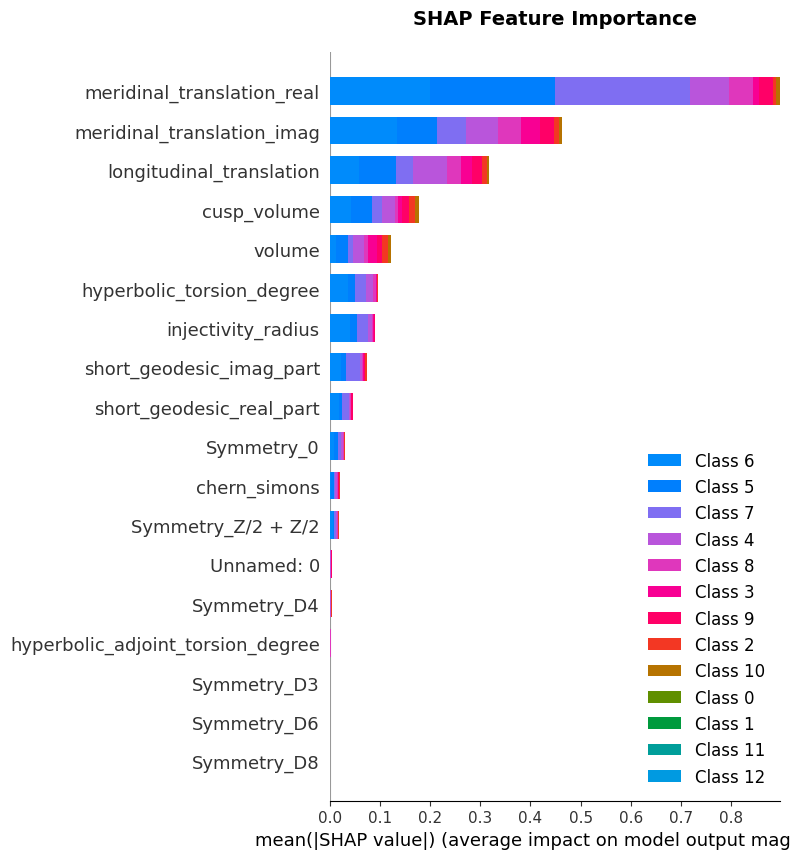

In [43]:
if explainer:
    plot = plot_shap_summary_fig_view_patch(explainer=explainer, X_sample=X_test, max_samples=10)

# Run TSNE and PCA

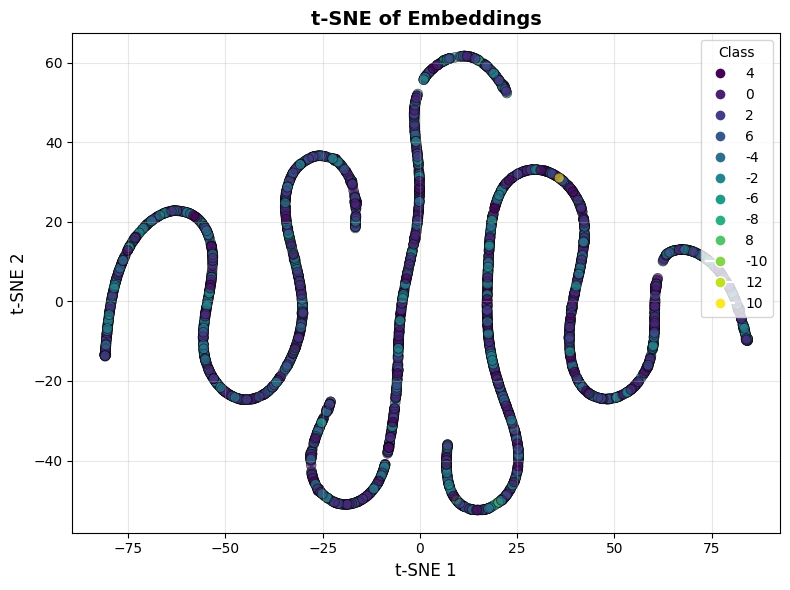

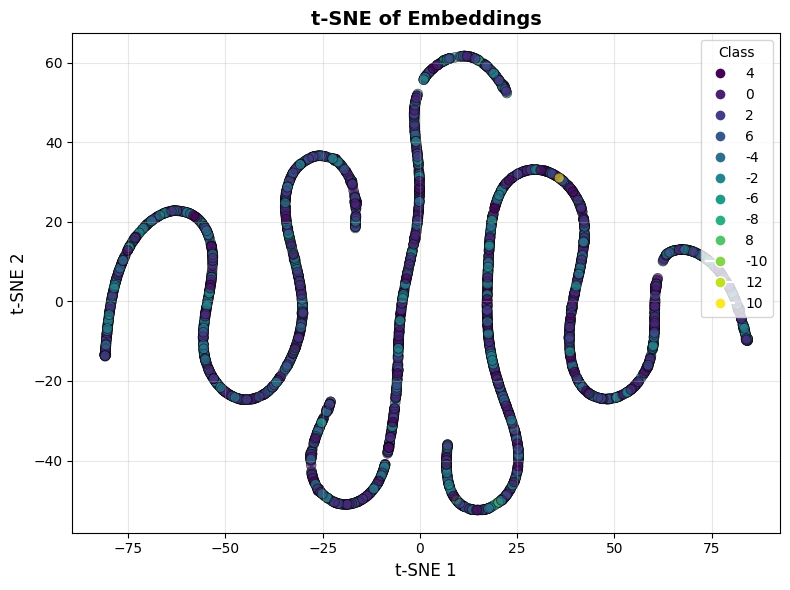

In [ ]:
embeddings = predictor.transform_features(X_test)
plot_embeddings_tsne_fig_patch(embeddings=embeddings, y=y_test)

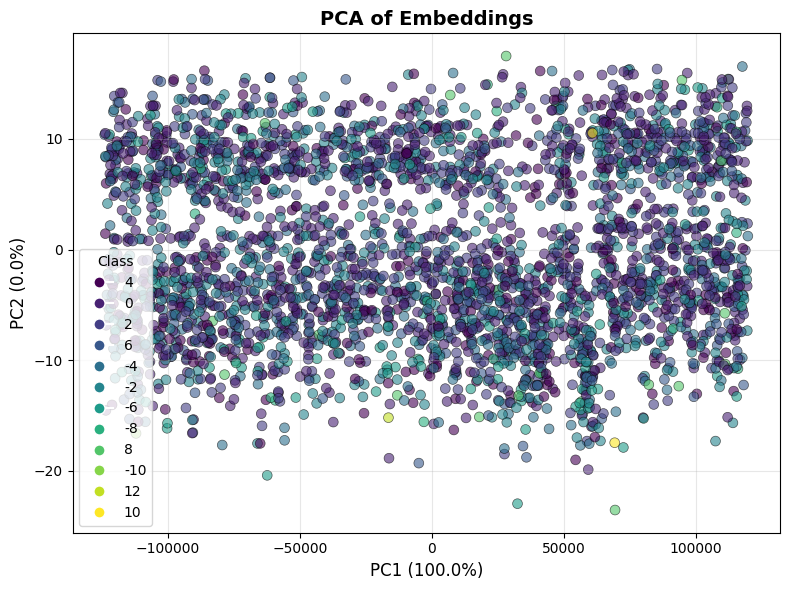

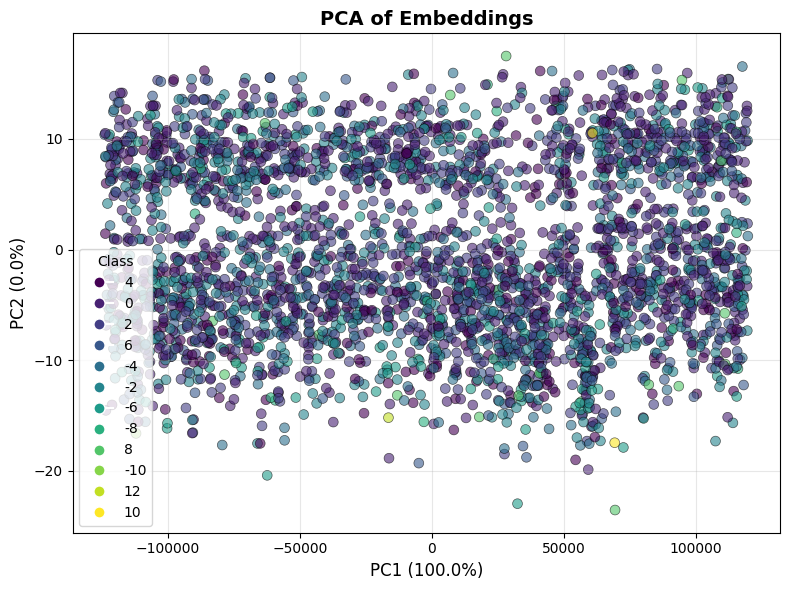

In [76]:
plot_embeddings_pca_fig_patch(embeddings=embeddings, y=y_test)

# Feature Importance

In [86]:
predictor.feature_importance(df)

These features in provided data are not utilized by the predictor and will be ignored: ['Symmetry_D8']


,importance,stddev,p_value,n,p99_high,p99_low
meridinal_translation_real,0.54260,0.005413,1.188337e-09,5,0.553745,0.531455
meridinal_translation_imag,0.40892,0.010822,5.880648e-08,5,0.431202,0.386638
longitudinal_translation,0.32864,0.009394,8.002696e-08,5,0.347982,0.309298
cusp_volume,0.12472,0.006891,1.114068e-06,5,0.138910,0.110530
volume,0.12444,0.004201,1.556226e-07,5,0.133090,0.115790
short_geodesic_imag_part,0.08384,0.005060,1.584969e-06,5,0.094260,0.073420
hyperbolic_torsion_degree,0.07228,0.004634,2.015940e-06,5,0.081821,0.062739
injectivity_radius,0.04900,0.004459,8.136737e-06,5,0.058181,0.039819
short_geodesic_real_part,0.02716,0.001774,2.173024e-06,5,0.030813,0.023507
Symmetry_Z/2 + Z/2,0.01568,0.002062,3.507801e-05,5,0.019926,0.011434


# Confusion Matrix and ROC Curve

In [137]:
def plot_confusion_matrix(y_true, y_pred, classes) -> Optional[str]:
    """Generate confusion matrix visualization."""
    try:
        cm = confusion_matrix(y_true, y_pred, labels=classes)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        
        fig, ax = plt.subplots(figsize=(7, 6))
        disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
        ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
        plt.tight_layout()
        
        # return fig_to_base64(fig)
        return fig
    except Exception as e:
        print(f"Confusion matrix plot failed: {e}")
        return None


def plot_roc_curve(y_true, y_proba, classes) -> Optional[str]:
    """Generate ROC curve (binary or multiclass micro-average)."""
    try:
    
        y_bin = label_binarize(y_true, classes=classes)
        if y_bin.shape[1] <= 1:
            return None

        # Compute micro-average ROC curve
        fpr, tpr, _ = roc_curve(y_bin.ravel(), y_proba.ravel())  # only if shapes match
        # OR better:
        auc = roc_auc_score(y_bin, y_proba, average="micro", multi_class="ovr")

        # Plot
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.plot(fpr, tpr, linewidth=2, label=f"Micro-avg AUC = {auc:.3f}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
        ax.set_xlabel("False Positive Rate", fontsize=12)
        ax.set_ylabel("True Positive Rate", fontsize=12)
        ax.set_title("ROC Curve (Micro-Average)", fontsize=14, fontweight="bold")
        ax.legend(loc="lower right")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        # return fig_to_base64(fig)
        return fig
    except Exception as e:
        print(f"ROC curve plot failed: {e}")
        return None

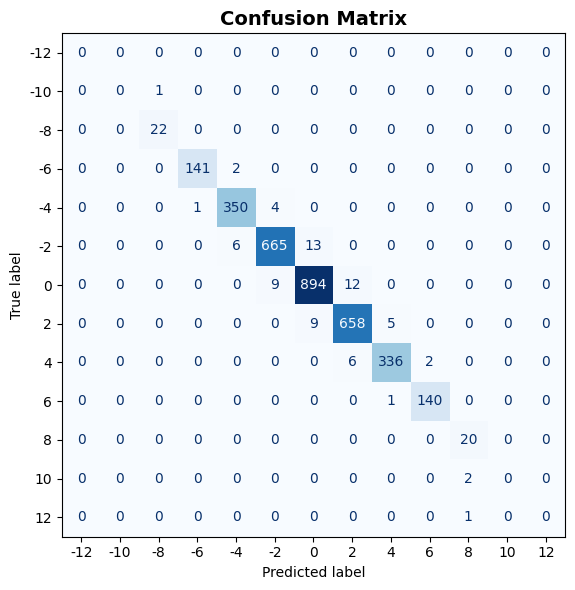

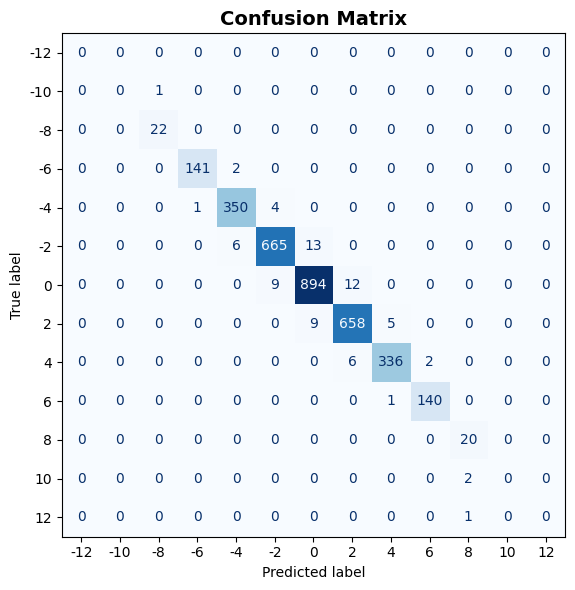

In [115]:
y_pred = predictor.predict(X_test)

plot_confusion_matrix(y_test, y_pred, predictor.class_labels)

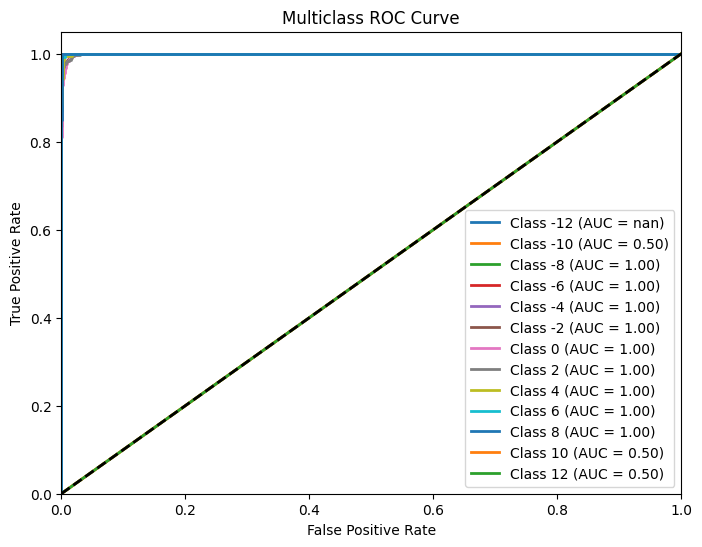

In [144]:
from sklearn.metrics import roc_curve, auc
def plot_multiclass_roc(model_wrapper, X_test, y_test, class_names=None):
    """
    Plots ROC curves for a multiclass classification model.

    Args:
        model_wrapper: Model wrapper with `predict` returning class probabilities (DataFrame).
        X_test: Test features.
        y_test: True labels.
        class_names: List of class names. If None, inferred from y_test.
    """
    # Get predicted probabilities
    y_score = model_wrapper.predict(X_test).values  # shape (n_samples, n_classes)
    
    # Classes
    classes = class_names if class_names is not None else model_wrapper.ag_model.class_labels
    n_classes = len(classes)
    
    # Binarize the output for multiclass ROC
    y_test_bin = label_binarize(y_test, classes=classes)
    
    # Plot ROC curve for each class
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

ag_wrapper = AutogluonWrapper(predictor, feature_names = X_train.columns)
plot_multiclass_roc(ag_wrapper, X_test=X_test, y_test=y_test, class_names=predictor.class_labels)